# BDG2 — Choix d’un bâtiment exploitable
Comparer les bâtiments Office et retenir **Hog_office_Miriam** pour une première modélisation sur 2016–2017. La sélection combine couverture, anomalies de mesure, stabilité mensuelle et profils d’activité ; la corrélation météo reste descriptive.


## Critères de sélection
La période est fixée du **1er janvier 2016 à 00 h au 31 décembre 2017 à 23 h**, soit **17 544 heures** (2016 est bissextile). Un bâtiment est éligible si chaque heure possède une consommation strictement positive et finie : aucun trou, zéro, négatif ou infini, et 24 mois complets. Ce filtre conservateur ne prouve pas à lui seul la qualité du compteur ; des zéros peuvent correspondre à un arrêt réel.

Le classement et la comparaison détaillée vérifient ensuite les séquences constantes, la stabilité mensuelle et les profils d’activité. Miriam est comparé à Napoleon, Myles, Antonina et Karla. Les zéros initiaux de Karla l’excluent du périmètre complet même si ses timestamps commencent en janvier 2016.


In [1]:
# Cellule 1 — Explorer la structure du dossier téléchargé
import os

for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:  # limite l'affichage si beaucoup de fichiers
        print(f"{indent}  {f}")

data/
  metadata/
    metadata.csv
  weather/
    weather.csv
  meters/
    cleaned/
      irrigation_cleaned.csv
      hotwater_cleaned.csv
      electricity_cleaned.csv
      chilledwater_cleaned.csv
      steam_cleaned.csv
    kaggle/
      kaggle.csv
    raw/
      hotwater.csv
      water.csv
      irrigation.csv
      solar.csv
      chilledwater.csv


In [2]:
# Cellule 2 — Imports
import numpy as np
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)

In [3]:
# Cellule 3 — Charger les métadonnées bâtiment
metadata = pd.read_csv("data/metadata/metadata.csv")
print(metadata.shape)
metadata.head()

(1636, 32)
Out[3]: 
                 building_id  site_id  building_id_kaggle  site_id_kaggle  \
0       Panther_lodging_Dean  Panther                 NaN             0.0   
1     Panther_lodging_Shelia  Panther                 NaN             0.0   
2      Panther_lodging_Ricky  Panther                 NaN             0.0   
3  Panther_education_Rosalie  Panther                 0.0             0.0   
4    Panther_education_Misty  Panther                 1.0             0.0   

     primaryspaceusage sub_primaryspaceusage    sqm     sqft        lat  \
0  Lodging/residential        Residence Hall  508.8   5477.0  28.517689   
1  Lodging/residential        Residence Hall  929.0  10000.0  28.517689   
2  Lodging/residential        Residence Hall  483.1   5200.0  28.517689   
3            Education              Research  690.5   7432.0  28.517689   
4            Education              Research  252.7   2720.0  28.517689   

         lng  ... yearbuilt date_opened numberoffloors occupants  

In [4]:
# Cellule 4 — Filtrer sur les bâtiments de type "Office"
offices = metadata[metadata["primaryspaceusage"] == "Office"]
print(f"{len(offices)} bâtiments de type Office")
offices[["building_id", "site_id", "sqft", "yearbuilt", "timezone"]].head(10)

307 bâtiments de type Office
Out[4]: 
                 building_id  site_id      sqft  yearbuilt    timezone
5       Panther_office_Daina  Panther    1440.0     1983.0  US/Eastern
7     Panther_office_Woodrow  Panther    5789.0     1996.0  US/Eastern
16      Panther_office_Karla  Panther   27000.0     2010.0  US/Eastern
23     Panther_office_Graham  Panther   83957.0     1974.0  US/Eastern
25    Panther_office_Valarie  Panther   15250.0     1980.0  US/Eastern
29      Panther_office_Larry  Panther   18717.0     2004.0  US/Eastern
32      Panther_office_Jeane  Panther    7043.0     1990.0  US/Eastern
36      Panther_office_Jesus  Panther  103286.0     1969.0  US/Eastern
37  Panther_office_Catherine  Panther   26953.0     2005.0  US/Eastern
40      Panther_office_Garth  Panther   52957.0     2016.0  US/Eastern


In [5]:
# Cellule 5 — Charger le compteur électricité (ajustez le chemin selon ce que la cellule 1 a montré)
electricity = pd.read_csv("data/meters/raw/electricity.csv", parse_dates=["timestamp"])
print(electricity.shape)
electricity.head()

(17544, 1579)
Out[5]: 
            timestamp  Panther_parking_Lorriane  Panther_lodging_Cora  \
0 2016-01-01 00:00:00                       0.0                   0.0   
1 2016-01-01 01:00:00                       0.0                   0.0   
2 2016-01-01 02:00:00                       0.0                   0.0   
3 2016-01-01 03:00:00                       0.0                   0.0   
4 2016-01-01 04:00:00                       0.0                   0.0   

   Panther_office_Hannah  Panther_lodging_Hattie  Panther_education_Teofila  \
0                    0.0                     0.0                        0.0   
1                    0.0                     0.0                        0.0   
2                    0.0                     0.0                        0.0   
3                    0.0                     0.0                        0.0   
4                    0.0                     0.0                        0.0   

   Panther_education_Jerome  Panther_retail_Felix  Panther_park

In [6]:
# Comparer les bâtiments Office avant de décider lequel retenir
# Un timestamp invalide ou dupliqué bloque le diagnostic et la fusion.
def check_timestamps(frame, label):
    if frame["timestamp"].isna().any():
        raise ValueError(f"{label} : timestamps manquants ou invalides")
    duplicates = frame["timestamp"].duplicated(keep=False)
    if duplicates.any():
        display(frame.loc[duplicates].head(10))
        raise ValueError(f"{label} : {duplicates.sum()} lignes avec timestamp dupliqué")

check_timestamps(electricity, "Électricité")
electricity = electricity.sort_values("timestamp").set_index("timestamp")
if electricity.empty:
    raise ValueError("La série électrique est vide")
# Période imposée : ne pas déduire les bornes des seules données présentes.
PERIOD_START = pd.Timestamp("2016-01-01 00:00:00")
PERIOD_END = pd.Timestamp("2017-12-31 23:00:00")
expected_hours = pd.date_range(PERIOD_START, PERIOD_END, freq="h")
in_period = electricity.loc[PERIOD_START:PERIOD_END]
if not in_period.index.isin(expected_hours).all():
    raise ValueError("Des timestamps électriques sont hors de la grille horaire")
missing_hours = expected_hours.difference(in_period.index)
print(f"Période demandée : {PERIOD_START} → {PERIOD_END} ({len(expected_hours)} heures)")
print(f"Heures absentes du fichier sur cette période : {len(missing_hours)}")
electricity = in_period.reindex(expected_hours).rename_axis("timestamp")
office_ids_with_data = [b for b in offices["building_id"].drop_duplicates() if b in electricity.columns]
print(f"{len(office_ids_with_data)} bâtiments Office ont une colonne électricité")

def longest_run(mask):
    groups = mask.ne(mask.shift()).cumsum()
    return int(mask.groupby(groups).sum().max()) if len(mask) else 0

def assess_coverage(values):
    """Éligibilité stricte sur chaque heure attendue, sans imputation."""
    values = values.reindex(expected_hours)
    valid = values.notna() & values.gt(0) & np.isfinite(values)
    valid_monthly = valid.resample("MS").sum()
    expected_monthly = valid.resample("MS").size()
    return {
        "first_positive": values.loc[valid].index.min(),
        "last_positive": values.loc[valid].index.max(),
        "missing_pct": 100 * values.isna().mean(),
        "zero_pct": 100 * values.eq(0).mean(),
        "negative_count": int(values.lt(0).sum()),
        "nonfinite_count": int((values.notna() & ~np.isfinite(values)).sum()),
        "longest_missing_hours": longest_run(values.isna()),
        "longest_zero_hours": longest_run(values.eq(0)),
        "positive_hours": int(valid.sum()),
        "complete_months": int(valid_monthly.eq(expected_monthly).sum()),
        "min_monthly_valid_pct": 100 * (valid_monthly / expected_monthly).min(),
        "eligible_full_period": bool(valid.all()),
    }

quality_rows = []
for candidate in office_ids_with_data:
    values = electricity[candidate]
    monthly_medians = values.resample("MS").median()
    quality_rows.append({
        "building_id": candidate,
        **assess_coverage(values),
        "longest_constant_hours": int(values.groupby(
            values.ne(values.shift()).cumsum()).size().max()),
        "monthly_median_ratio": (
            monthly_medians.max() / monthly_medians.min()
            if monthly_medians.min() > 0 else float("inf")
        ),
    })
quality = pd.DataFrame(quality_rows)
if quality.empty:
    raise ValueError("Aucun bâtiment Office avec une colonne électricité")
quality = quality.sort_values(
    ["eligible_full_period", "negative_count", "missing_pct", "longest_zero_hours", "zero_pct", "building_id"],
    ascending=[False, True, True, True, True, True]
).reset_index(drop=True)
display(quality.head(20))
print(f"Bâtiments éligibles sur les 24 mois : {quality.eligible_full_period.sum()}")

# Choix explicite après comparaison ; aucune sélection par premier élément.
building_id = "Hog_office_Miriam"
if building_id not in office_ids_with_data:
    raise ValueError(f"{building_id} absent des bâtiments Office disponibles")
selected_quality = quality.set_index("building_id").loc[building_id]
if not selected_quality["eligible_full_period"]:
    raise ValueError(f"{building_id} ne couvre pas intégralement 2016–2017 avec des mesures positives finies")
display(selected_quality.to_frame().T)
df_building = electricity[[building_id]].reset_index().rename(
    columns={building_id: "consumption_kwh"}
)
print(f"Bâtiment retenu : {building_id} ({len(df_building)} heures)")
df_building.head()


Période demandée : 2016-01-01 00:00:00 → 2017-12-31 23:00:00 (17544 heures)
Heures absentes du fichier sur cette période : 0
296 bâtiments Office ont une colonne électricité
Bâtiments éligibles sur les 24 mois : 34
Bâtiment retenu : Hog_office_Miriam (17544 heures)
Out[6]: 
            timestamp  consumption_kwh
0 2016-01-01 00:00:00           15.738
1 2016-01-01 01:00:00           15.738
2 2016-01-01 02:00:00           15.569
3 2016-01-01 03:00:00           15.337
4 2016-01-01 04:00:00           15.651


,building_id,first_positive,last_positive,missing_pct,zero_pct,negative_count,nonfinite_count,longest_missing_hours,longest_zero_hours,positive_hours,complete_months,min_monthly_valid_pct,eligible_full_period,longest_constant_hours,monthly_median_ratio
0,Hog_office_Almeda,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,14,1.489966
1,Hog_office_Bessie,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,73,1.394737
2,Hog_office_Betsy,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,4,5.032341
3,Hog_office_Bill,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,9,2.248770
4,Hog_office_Denita,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,3,1.485912
5,Hog_office_Gustavo,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,3,13.763762
6,Hog_office_Lavon,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,26,50.451867
7,Hog_office_Lizzie,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,9,1.452930
8,Hog_office_Mary,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,3,1.690910
9,Hog_office_Merilyn,2016-01-01,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,338,2.398126


,first_positive,last_positive,missing_pct,zero_pct,negative_count,nonfinite_count,longest_missing_hours,longest_zero_hours,positive_hours,complete_months,min_monthly_valid_pct,eligible_full_period,longest_constant_hours,monthly_median_ratio
Hog_office_Miriam,2016-01-01 00:00:00,2017-12-31 23:00:00,0.0,0.0,0,0,0,0,17544,24,100.0,True,3,1.404449


Karla — couverture mensuelle (les zéros ne sont pas des heures exploitables selon le filtre)


,first_positive,last_positive,missing_pct,zero_pct,negative_count,nonfinite_count,longest_missing_hours,longest_zero_hours,positive_hours,complete_months,min_monthly_valid_pct,eligible_full_period,longest_constant_hours,monthly_median_ratio,weekend_vs_weekday
building_id,,,,,,,,,,,,,,,
Hog_office_Miriam,2016-01-01 00:00:00,2017-12-31 23:00:00,0.000000,0.000000,0,0,0,0,17544,24,100.0,True,3,1.404449,0.773944
Hog_office_Napoleon,2016-01-01 00:00:00,2017-12-31 23:00:00,0.000000,0.000000,0,0,0,0,17544,24,100.0,True,7,1.175896,0.822338
Hog_office_Myles,2016-01-01 00:00:00,2017-12-31 23:00:00,0.000000,0.000000,0,0,0,0,17544,24,100.0,True,199,1.372746,0.601963
Robin_office_Antonina,2016-01-01 00:00:00,2017-12-31 23:00:00,0.000000,0.000000,0,0,0,0,17544,24,100.0,True,72,1.285797,0.826085
Panther_office_Karla,2016-05-01 19:00:00,2017-12-31 23:00:00,0.062699,19.248746,0,0,6,2923,14156,16,0.0,False,2923,inf,0.681898


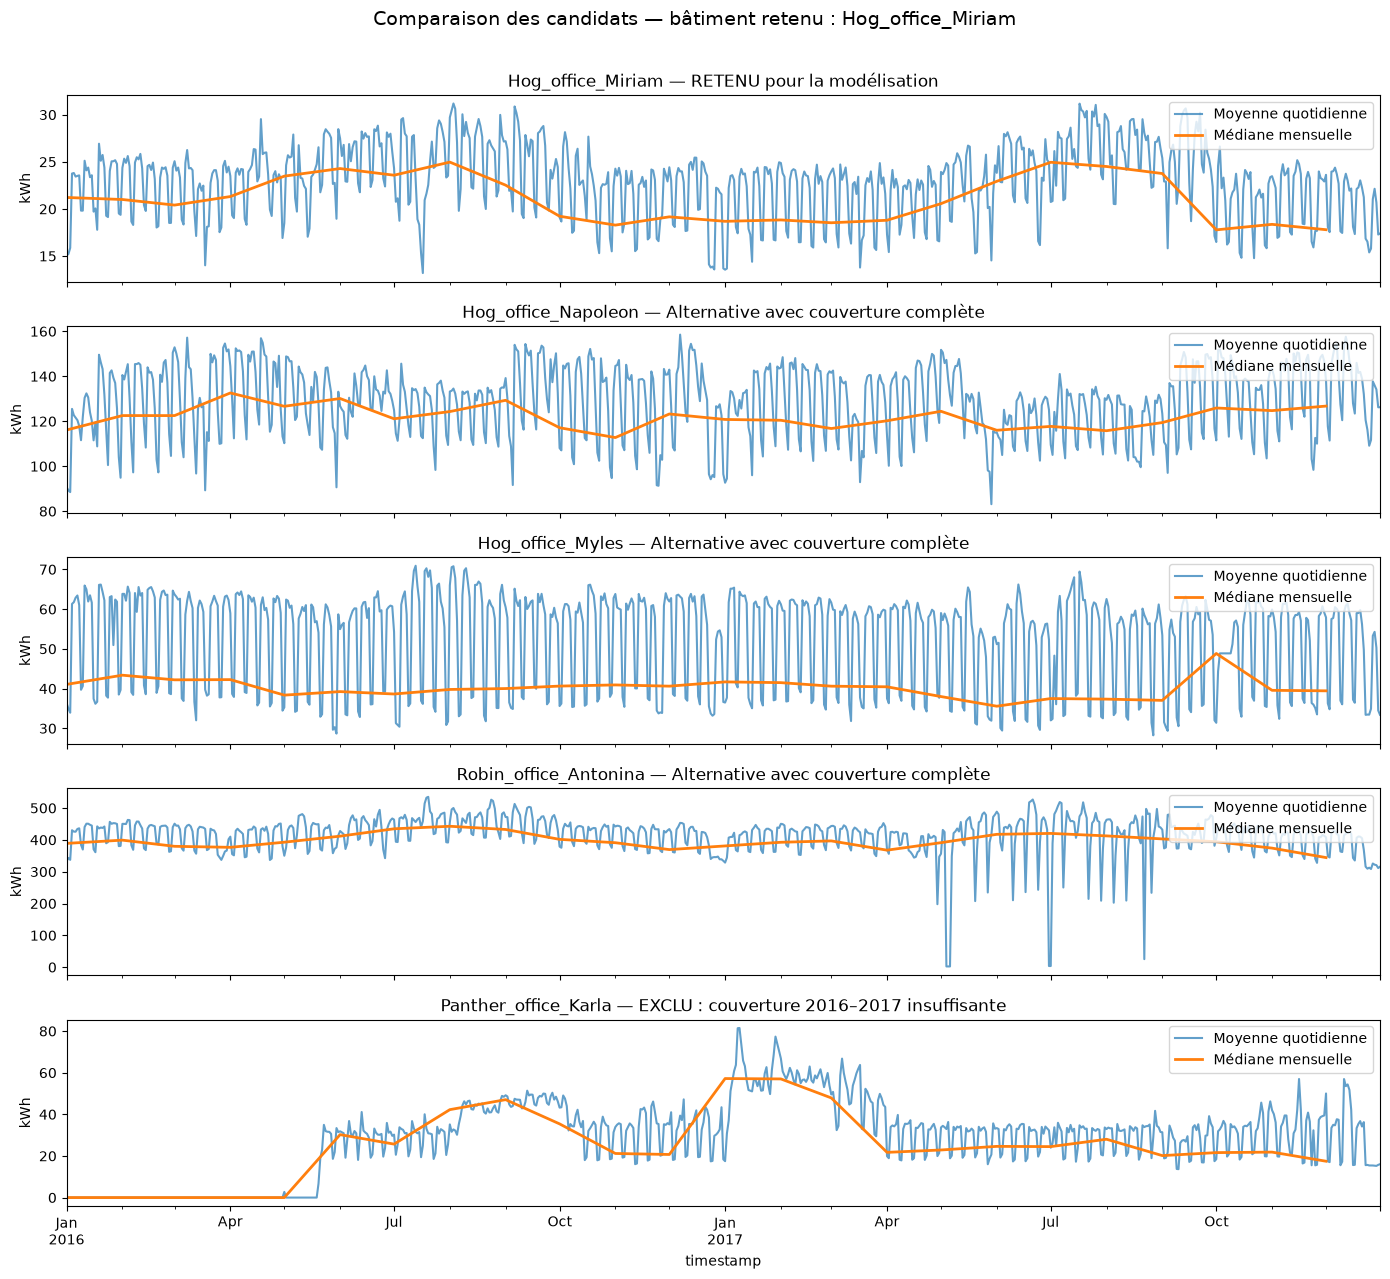

,expected_hours,missing_hours,zero_hours,valid_hours
timestamp,,,,
2016-01-01,744,0,744,0
2016-02-01,696,0,696,0
2016-03-01,744,0,744,0
2016-04-01,720,0,720,0
2016-05-01,744,0,473,271
2016-06-01,720,0,0,720
2016-07-01,744,0,0,744
2016-08-01,744,0,0,744
2016-09-01,720,0,0,720


In [7]:
# Comparaison détaillée : qualité, stabilité et activité
candidate_ids = ["Hog_office_Miriam", "Hog_office_Napoleon", "Hog_office_Myles",
                 "Robin_office_Antonina", "Panther_office_Karla"]
comparison = quality.set_index("building_id").loc[candidate_ids].copy()
comparison["weekend_vs_weekday"] = [
    electricity[b][electricity.index.dayofweek >= 5].mean()
    / electricity[b][electricity.index.dayofweek < 5].mean()
    for b in candidate_ids
]
display(comparison)
fig, axes = plt.subplots(len(candidate_ids), 1, figsize=(14, 13), sharex=True)
for ax, candidate in zip(axes, candidate_ids):
    series = electricity[candidate]
    series.resample("D").mean().plot(ax=ax, label="Moyenne quotidienne", alpha=0.7)
    series.resample("MS").median().plot(ax=ax, label="Médiane mensuelle", linewidth=2)
    status = (
        "RETENU pour la modélisation" if candidate == building_id
        else "EXCLU : couverture 2016–2017 insuffisante"
        if not comparison.loc[candidate, "eligible_full_period"]
        else "Alternative avec couverture complète"
    )
    ax.set_title(f"{candidate} — {status}")
    ax.set_ylabel("kWh")
    ax.legend(loc="upper right")
fig.suptitle("Comparaison des candidats — bâtiment retenu : " + building_id, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
karla = electricity["Panther_office_Karla"]
print("Karla — couverture mensuelle (les zéros ne sont pas des heures exploitables selon le filtre)")
display(pd.DataFrame({
    "expected_hours": karla.resample("MS").size(),
    "missing_hours": karla.isna().resample("MS").sum(),
    "zero_hours": karla.eq(0).resample("MS").sum(),
    "valid_hours": (karla.gt(0) & np.isfinite(karla)).resample("MS").sum(),
}))


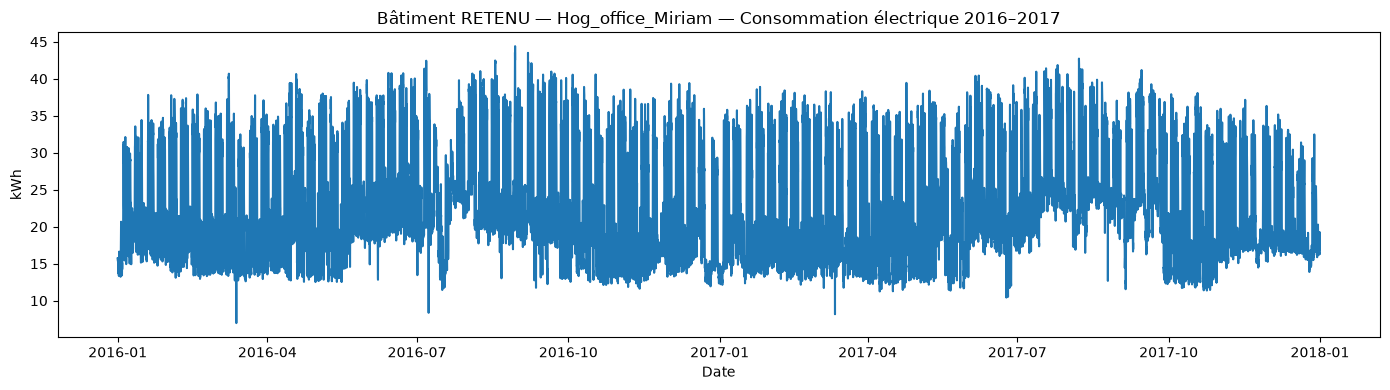

In [8]:
# Cellule 7 — Visualiser la série temporelle
plt.figure(figsize=(14, 4))
plt.plot(df_building["timestamp"], df_building["consumption_kwh"])
plt.title(f"Bâtiment RETENU — {building_id} — Consommation électrique 2016–2017")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.tight_layout()
plt.show()

In [9]:
# Cellule 8 — Charger la météo du site correspondant
site_id = offices[offices["building_id"] == building_id]["site_id"].iloc[0]
weather = pd.read_csv("data/weather/weather.csv", parse_dates=["timestamp"])
weather_site = weather[weather["site_id"] == site_id]
print(weather_site.shape)
weather_site.head()

(17542, 10)
Out[9]: 
                 timestamp site_id  airTemperature  cloudCoverage  \
261597 2016-01-01 00:00:00     Hog            -7.2            8.0   
261598 2016-01-01 01:00:00     Hog            -6.7            NaN   
261599 2016-01-01 02:00:00     Hog            -6.7            NaN   
261600 2016-01-01 03:00:00     Hog            -6.7            NaN   
261601 2016-01-01 04:00:00     Hog            -8.3            NaN   

        dewTemperature  precipDepth1HR  precipDepth6HR  seaLvlPressure  \
261597           -10.6             0.0            -1.0          1022.9   
261598           -10.0            -1.0             NaN          1022.5   
261599            -9.4             0.0             NaN          1022.1   
261600            -9.4            -1.0             NaN          1022.0   
261601           -11.7             0.0             NaN          1021.9   

        windDirection  windSpeed  
261597          280.0        5.7  
261598          280.0        4.1  
261599        

In [10]:
# Couverture météo des candidats : valider la jointure pour chaque site
weather_quality = []
for candidate in candidate_ids:
    candidate_site = offices.loc[offices["building_id"].eq(candidate), "site_id"].iloc[0]
    candidate_weather = weather.loc[weather["site_id"].eq(candidate_site)]
    check_timestamps(candidate_weather, f"Météo {candidate_site}")
    joined = electricity[[candidate]].reset_index().merge(
        candidate_weather, on="timestamp", how="left", validate="one_to_one", indicator=True
    )
    weather_quality.append({
        "building_id": candidate,
        "hours_without_weather": int(joined["_merge"].eq("left_only").sum()),
        "missing_temperature": int(joined["airTemperature"].isna().sum()),
        "temperature_correlation": joined[candidate].corr(joined["airTemperature"]),
    })
display(pd.DataFrame(weather_quality))

,building_id,hours_without_weather,missing_temperature,temperature_correlation
0,Hog_office_Miriam,2,4,0.327563
1,Hog_office_Napoleon,2,4,0.070053
2,Hog_office_Myles,2,4,0.080477
3,Robin_office_Antonina,28,29,0.363777
4,Panther_office_Karla,0,3,0.177051


Valeurs manquantes (consommation) : 0
Valeurs à zéro : 0
Valeurs négatives : 0
count    17544.000000
mean        23.047986
std          7.241552
min          6.968500
25%         17.215500
50%         21.544500
75%         28.717500
max         44.405000
Name: consumption_kwh, dtype: float64
Séquences de valeurs manquantes (y compris heures absentes du fichier)
Séquences de zéros les plus longues


,start,end,hours


,start,end,hours


,mean_kwh,median_kwh,missing_hours,zero_hours,total_hours
timestamp,,,,,
2016-01-01,22.112773,21.2160,0,0,744
2016-02-01,22.990095,21.0005,0,0,696
2016-03-01,22.117601,20.4080,0,0,744
2016-04-01,23.185304,21.3140,0,0,720
2016-05-01,23.910663,23.4795,0,0,744
2016-06-01,26.070260,24.2845,0,0,720
2016-07-01,23.892704,23.5785,0,0,744
2016-08-01,26.558556,24.9690,0,0,744
2016-09-01,24.986778,22.5235,0,0,720


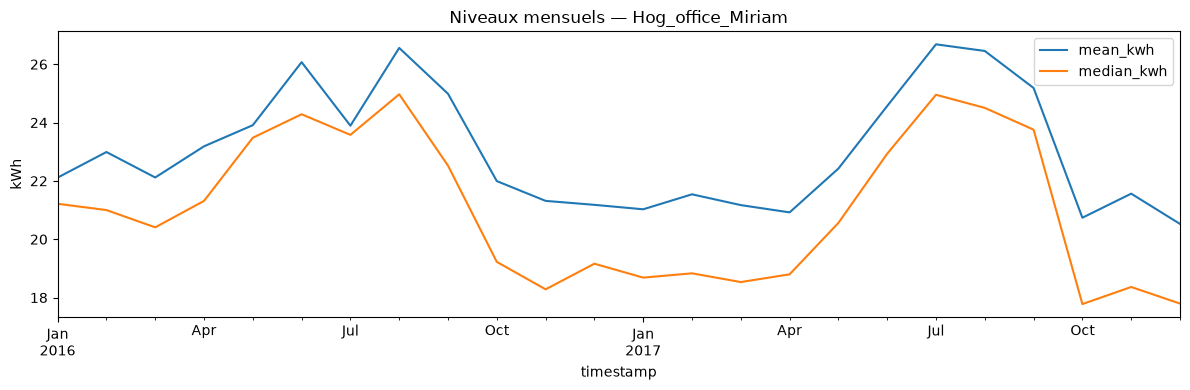

In [11]:
# Diagnostic sur la série complète : aucune suppression préalable
values = df_building["consumption_kwh"]
print("Valeurs manquantes (consommation) :", values.isna().sum())
print("Valeurs à zéro :", values.eq(0).sum())
print("Valeurs négatives :", values.lt(0).sum())
print(values.describe())

def describe_runs(frame, mask):
    groups = mask.ne(mask.shift()).cumsum()
    return (frame.loc[mask].assign(sequence=groups[mask])
            .groupby("sequence").agg(
                start=("timestamp", "min"),
                end=("timestamp", "max"),
                hours=("timestamp", "size"))
            .sort_values("hours", ascending=False).reset_index(drop=True))

missing_runs = describe_runs(df_building, values.isna())
zero_runs = describe_runs(df_building, values.eq(0))
print("Séquences de valeurs manquantes (y compris heures absentes du fichier)")
display(missing_runs.head(20))
print("Séquences de zéros les plus longues")
display(zero_runs.head(20))

monthly_quality = df_building.set_index("timestamp").resample("MS").agg(
    mean_kwh=("consumption_kwh", "mean"),
    median_kwh=("consumption_kwh", "median"),
    missing_hours=("consumption_kwh", lambda s: s.isna().sum()),
    zero_hours=("consumption_kwh", lambda s: s.eq(0).sum()),
    total_hours=("consumption_kwh", "size"),
)
display(monthly_quality)
monthly_quality[["mean_kwh", "median_kwh"]].plot(
    figsize=(12, 4), title=f"Niveaux mensuels — {building_id}"
)
plt.ylabel("kWh")
plt.tight_layout()
plt.show()
# Les changements de niveau et les zéros ne sont pas corrigés automatiquement :
# vérifier arrêt d'activité, défaut de mesure ou changement de compteur avant modélisation.

In [12]:
# Fusion de diagnostic : conserver toutes les heures de consommation
check_timestamps(df_building, "Consommation")
check_timestamps(weather_site, f"Météo du site {site_id}")
df_merged = pd.merge(
    df_building, weather_site, on="timestamp", how="left",
    validate="one_to_one", indicator="weather_match",
)
assert len(df_merged) == len(df_building)
print(f"Dataset fusionné : {len(df_merged)} lignes, {df_merged.shape[1]} colonnes")
print("Heures sans ligne météo :", df_merged["weather_match"].eq("left_only").sum())
print("Valeurs manquantes par colonne après fusion :")
print(df_merged.isna().sum())
df_merged.head()

Dataset fusionné : 17544 lignes, 12 colonnes
Heures sans ligne météo : 2
Valeurs manquantes par colonne après fusion :
timestamp              0
consumption_kwh        0
site_id                2
airTemperature         4
cloudCoverage       8640
dewTemperature         4
precipDepth1HR        53
precipDepth6HR     16815
seaLvlPressure       204
windDirection        445
windSpeed              4
weather_match          0
dtype: int64
Out[12]: 
            timestamp  consumption_kwh site_id  airTemperature  cloudCoverage  \
0 2016-01-01 00:00:00           15.738     Hog            -7.2            8.0   
1 2016-01-01 01:00:00           15.738     Hog            -6.7            NaN   
2 2016-01-01 02:00:00           15.569     Hog            -6.7            NaN   
3 2016-01-01 03:00:00           15.337     Hog            -6.7            NaN   
4 2016-01-01 04:00:00           15.651     Hog            -8.3            NaN   

   dewTemperature  precipDepth1HR  precipDepth6HR  seaLvlPressure  \
0 

In [13]:
# Cellule 11 — Extraction des composantes temporelles (Feature Engineering)
df_merged["hour"] = df_merged["timestamp"].dt.hour
df_merged["dayofweek"] = df_merged["timestamp"].dt.dayofweek  # 0=Lundi, 6=Dimanche
df_merged["day_name"] = df_merged["timestamp"].dt.day_name()
df_merged["month"] = df_merged["timestamp"].dt.month
df_merged["is_weekend"] = df_merged["dayofweek"].isin([5, 6]).astype(int)

df_merged[["timestamp", "consumption_kwh", "hour", "day_name", "is_weekend"]].head()

Out[13]: 
            timestamp  consumption_kwh  hour day_name  is_weekend
0 2016-01-01 00:00:00           15.738     0   Friday           0
1 2016-01-01 01:00:00           15.738     1   Friday           0
2 2016-01-01 02:00:00           15.569     2   Friday           0
3 2016-01-01 03:00:00           15.337     3   Friday           0
4 2016-01-01 04:00:00           15.651     4   Friday           0


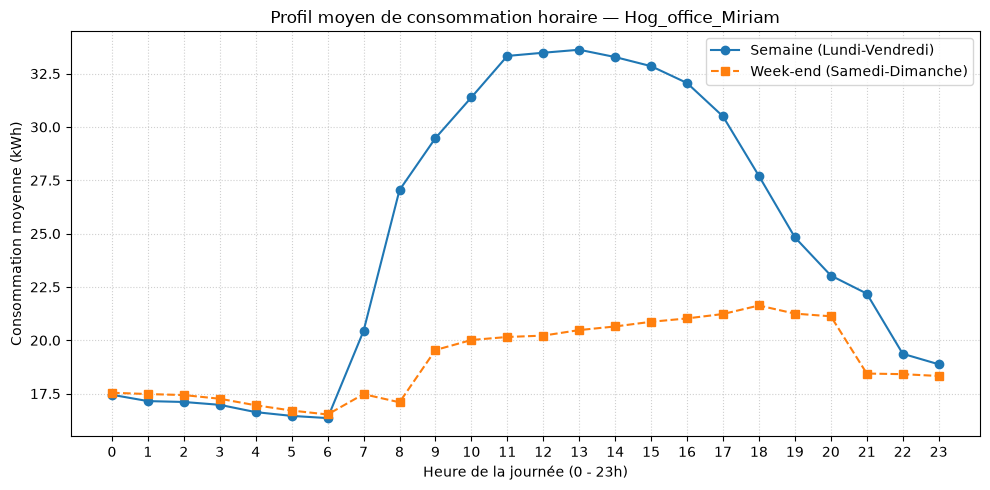

In [14]:
# Cellule 12 — Profil moyen de consommation horaire (Semaine vs Week-end)
hourly_profile = df_merged.groupby(["hour", "is_weekend"])["consumption_kwh"].mean().unstack()

plt.figure(figsize=(10, 5))
plt.plot(hourly_profile.index, hourly_profile[0], label="Semaine (Lundi-Vendredi)", marker="o", color="#1f77b4")
plt.plot(hourly_profile.index, hourly_profile[1], label="Week-end (Samedi-Dimanche)", marker="s", color="#ff7f0e", linestyle="--")
plt.title(f"Profil moyen de consommation horaire — {building_id}")
plt.xlabel("Heure de la journée (0 - 23h)")
plt.ylabel("Consommation moyenne (kWh)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Corrélation consommation / température extérieure : 0.328


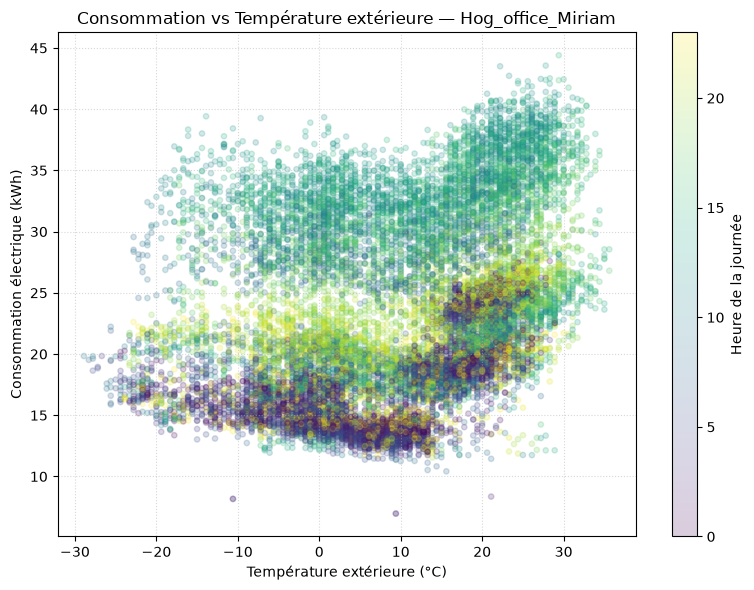

In [15]:
# Cellule 13 — Impact de la température extérieure sur la consommation
corr = df_merged["consumption_kwh"].corr(df_merged["airTemperature"])
print(f"Corrélation consommation / température extérieure : {corr:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(df_merged["airTemperature"], df_merged["consumption_kwh"], alpha=0.2, c=df_merged["hour"], cmap="viridis", s=15)
plt.colorbar(label="Heure de la journée")
plt.title(f"Consommation vs Température extérieure — {building_id}")
plt.xlabel("Température extérieure (°C)")
plt.ylabel("Consommation électrique (kWh)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## Décision et périmètre de travail
**Hog_office_Miriam est retenu** pour une première modélisation sur les deux années complètes : **17 544 mesures horaires positives et finies, 24 mois complets**, aucun trou, zéro ou négatif. La plus longue séquence constante dure 3 heures ; le rapport entre les médianes mensuelles extrêmes est de 1,40 et la consommation moyenne du week-end représente 77,4 % de celle des jours de semaine. Ces diagnostics motivent le choix parmi les 34 bureaux qui satisfont le filtre de couverture.

**Panther_office_Karla est exclu** : première mesure positive le **1er mai 2016 à 19 h**, après **2 923 heures consécutives à zéro** depuis le début de la période. Sur les deux années, il présente 3 377 zéros, 11 valeurs manquantes et seulement 16 mois entièrement valides. La présence de lignes dès janvier ne suffit donc pas à le rendre exploitable sur toute la période.

Napoleon constitue une alternative stable ; Myles et Antonina présentent respectivement des séquences constantes de 199 et 72 heures à examiner. Le filtre de couverture et les diagnostics ne certifient pas l’absence de toute anomalie ponctuelle.

Conserver la série électrique complète de Miriam. Pour un modèle utilisant la température, traiter explicitement les **quatre températures absentes** (deux heures sans ligne météo et deux mesures manquantes), sans imputer automatiquement les colonnes météo très incomplètes. Définir les transformations sur la période d’entraînement uniquement et utiliser une séparation chronologique pour l’évaluation.
